✓ HUT
✓ COUR
✓ SOC
✓ MU


Error 200, reqId 13: No security definition has been found for the request, contract: Stock(symbol='FOLD', exchange='SMART', currency='USD')
Unknown contract: Stock(symbol='FOLD', exchange='SMART', currency='USD')


✓ WGO


Error 200, reqId 14: No security definition has been found for the request, contract: Stock(symbol='FOLD', exchange='SMART', currency='USD')


[IB] No data for FOLD – skipping
✓ AXIA
✓ BIDU
✓ SMR
✓ CRNX


...

✓ DVA
[IB] No data for BITF – skipping
✓ VSAT
✓ CG
✓ RBLX
✓ NVST
✓ BILL
✓ EHC
✓ GLXY
✓ PWP
✓ VAL
✓ QS
✓ DT
✓ ROKU
✓ BROS


Error 200, reqId 127: No security definition has been found for the request, contract: Stock(symbol='TPH', exchange='SMART', currency='USD')
Unknown contract: Stock(symbol='TPH', exchange='SMART', currency='USD')
Error 200, reqId 128: No security definition has been found for the request, contract: Stock(symbol='TPH', exchange='SMART', currency='USD')


✓ SEI
[IB] No data for TPH – skipping
✓ CART
✓ AMAT
✓ MSGS
✓ WING
✓ GPN
✓ GRMN
✓ RSI
✓ PBI
✓ WTTR
✓ KOS
✓ RNG
✓ TNDM
✓ WK
✓ HLIT
✓ PVLA


Error 162, reqId 160: Historical Market Data Service error message:BEST queries are not supported for this contract, contract: Stock(conId=87713412, symbol='THR', exchange='SMART', primaryExchange='NYSE', currency='USD', localSymbol='THR', tradingClass='THR')


[IB] No data for THR – skipping
✓ IOVA
✓ KEYS
✓ BFLY
✓ SJM
✓ LMAT
✓ SHAK
✓ ARHS
✓ WWW
✓ CELH
✓ IONQ
✓ Q
✓ GCT
✓ VAC
✓ OPRA
✓ MARA
✓ XYZ
✓ FIGS
✓ NFLX
✓ REAL
✓ ARLO
✓ AAOI
✓ LASR
✓ ASTH
✓ VG
✓ AVAV
✓ NAT
✓ RTO
✓ TTD
✓ MRVL
✓ CAPR
✓ XENE
✓ DNTH
✓ BHVN
✓ HIMS
✓ PL


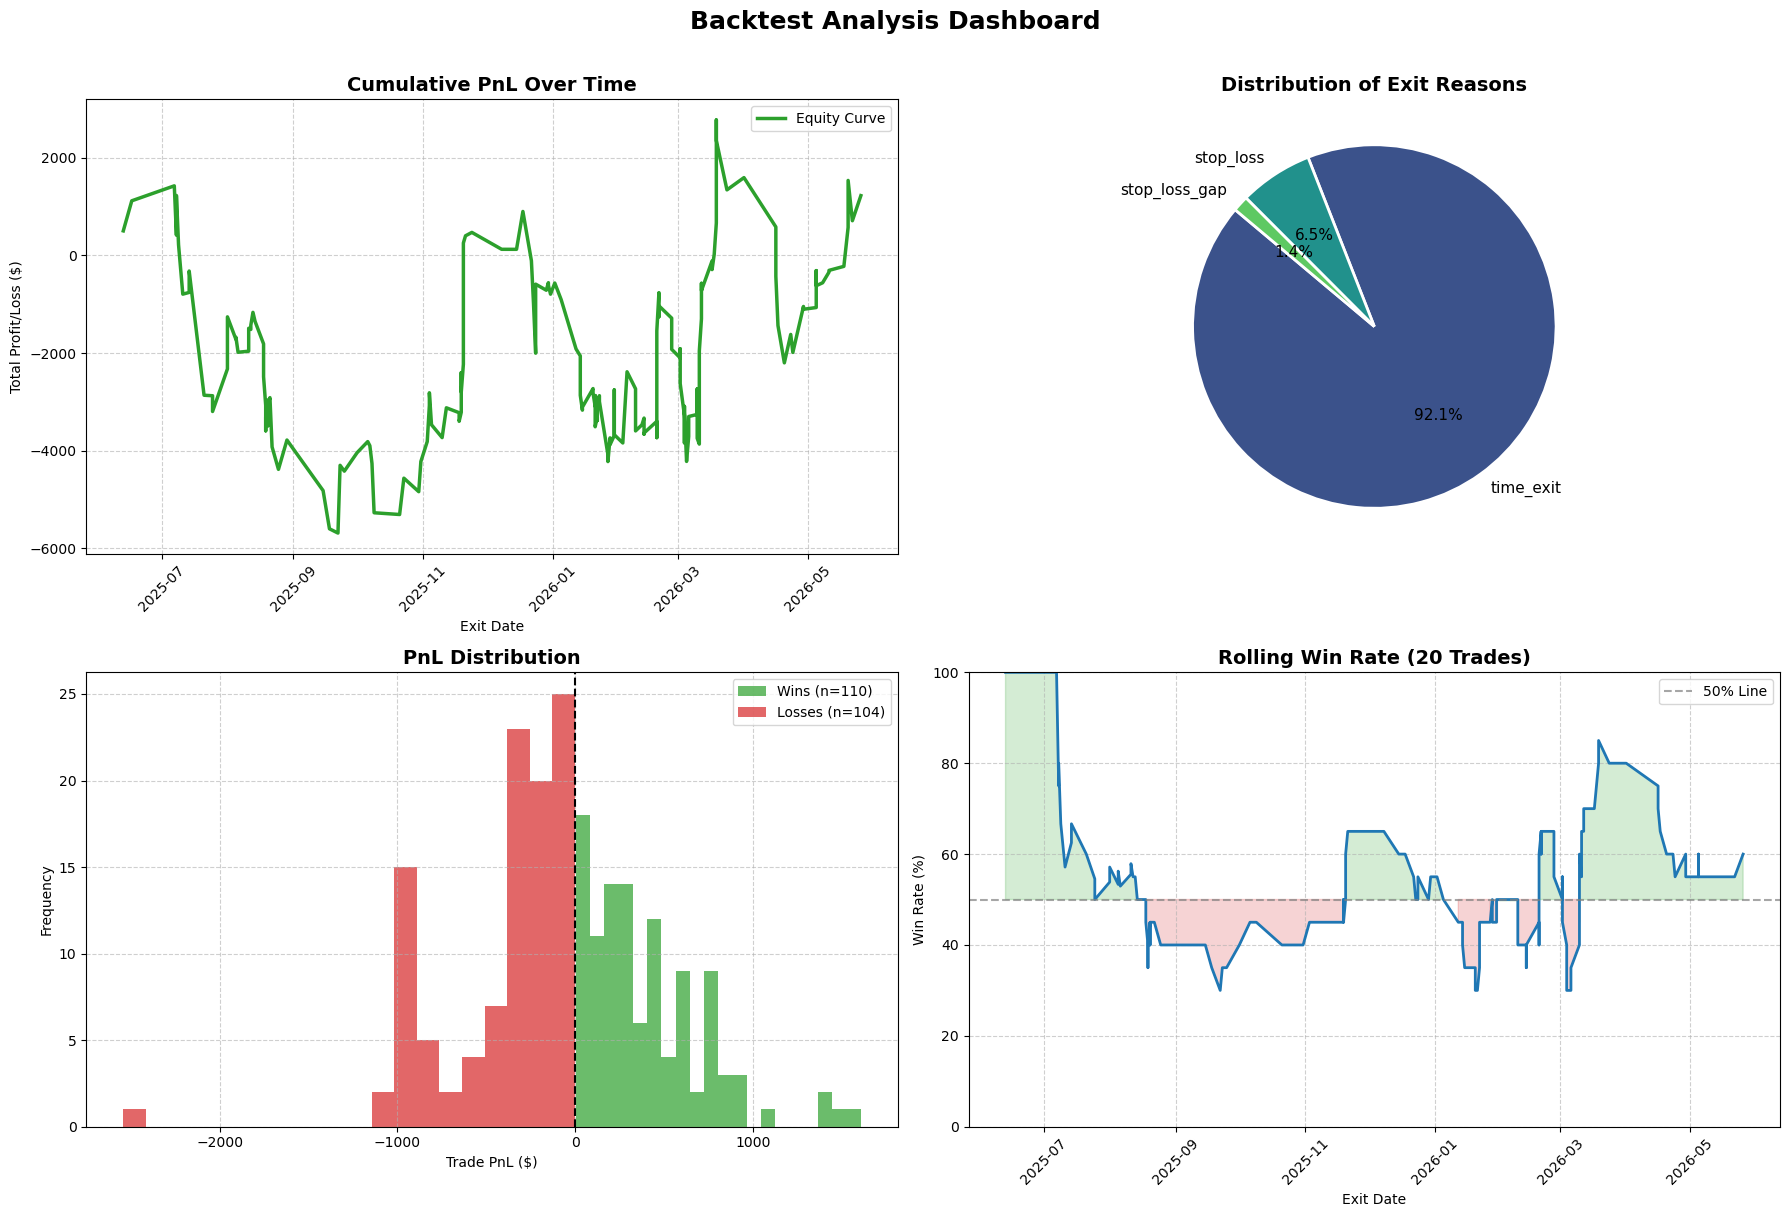

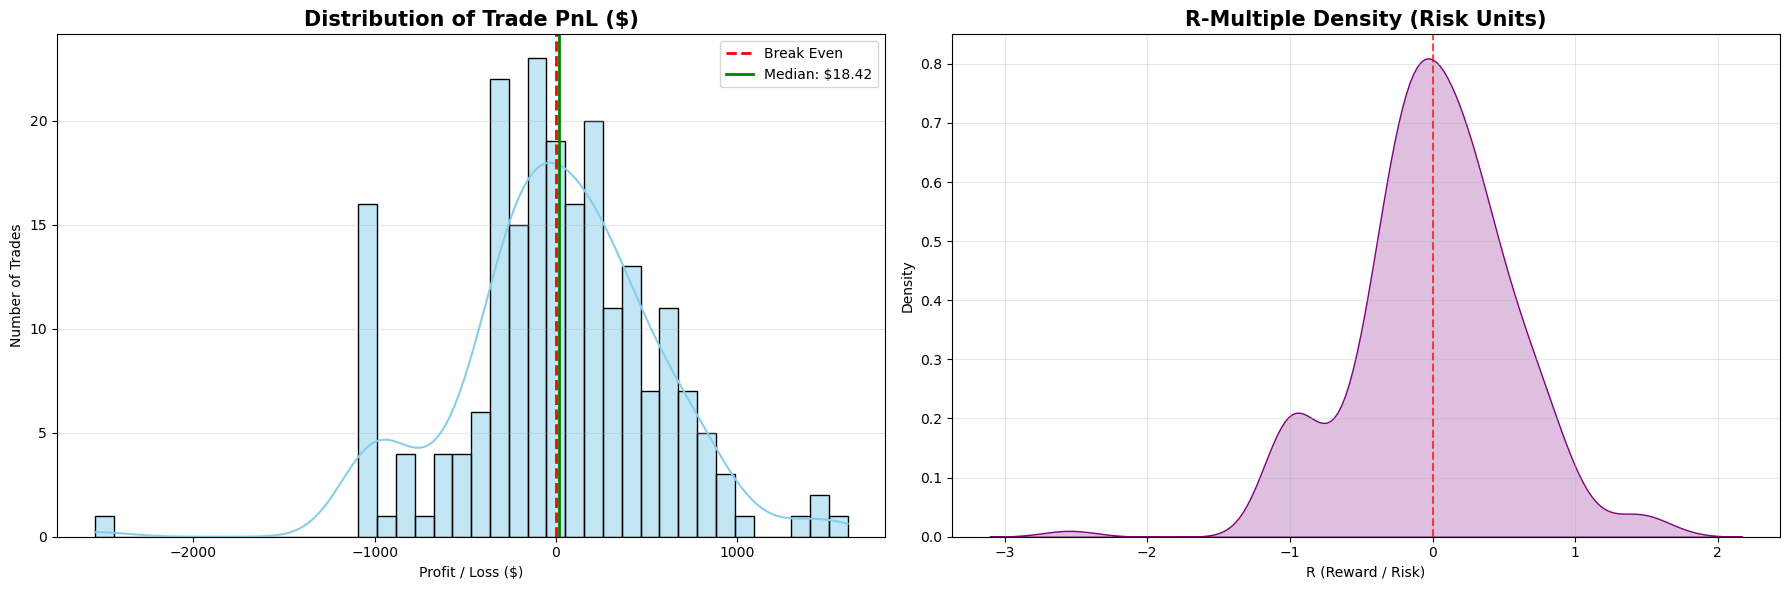

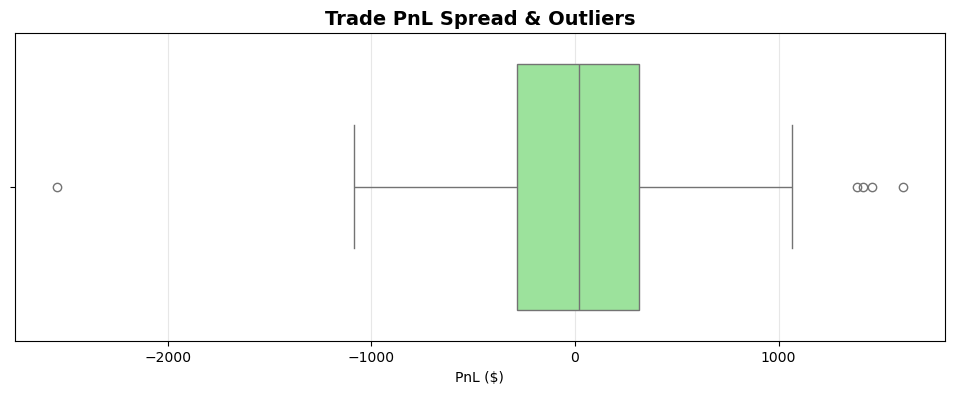

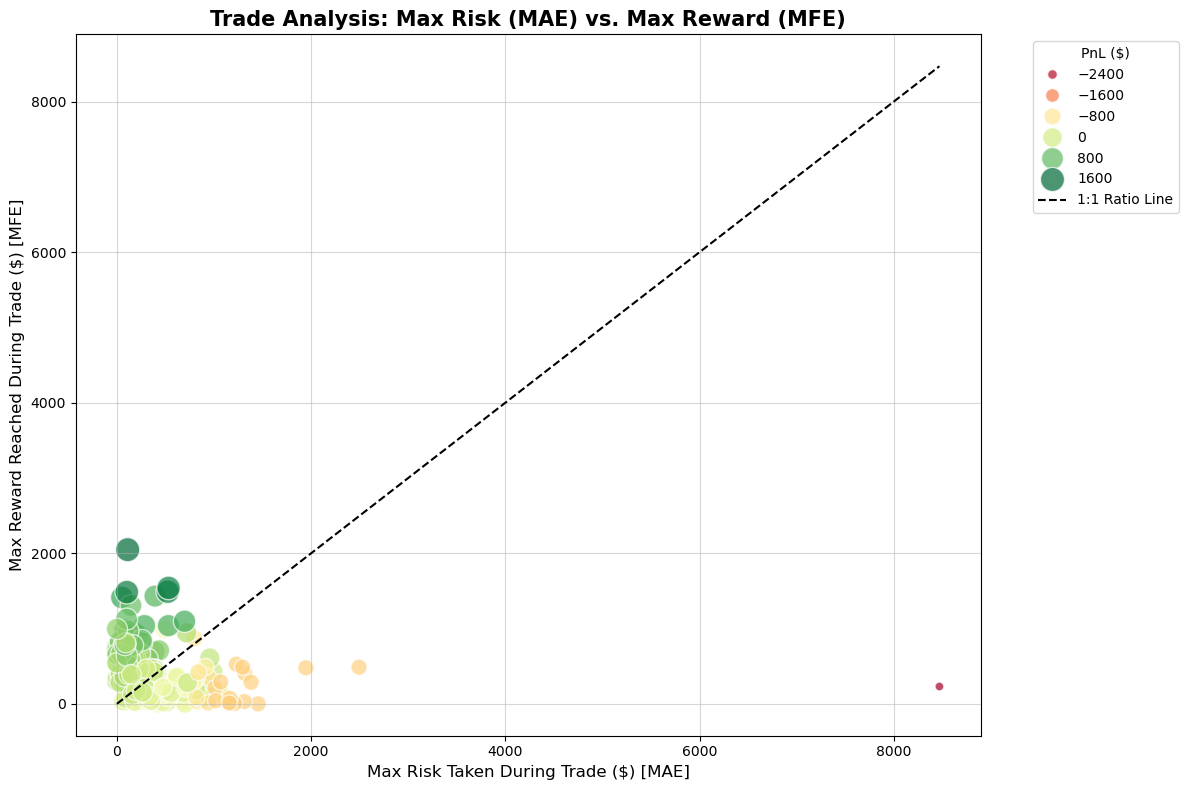

       BACKTEST SUMMARY
Total Trades:       214
Win Rate:           51.4%
Total PnL:          $1,223.49
Max Drawdown:       $-7,111.96
Profit Factor:      1.03
Median Win:         $311.69
Median Loss:        $-293.84
Avg Win:            $404.66
Avg Loss:           $-416.24
Avg R:              0.01R
Total R:            1.22R
----------------------------------------
Exit Reasons:
  time_exit             197 (92.1%)
  stop_loss              14 (6.5%)
  stop_loss_gap           3 (1.4%)


In [60]:
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress
from ib_insync import IB, Stock, util
from itertools import product

# ---------------------------------------------------------------------
# 1. STRATEGY PARAMETERS 
# ---------------------------------------------------------------------
STOP_LOSS_PCT   = 0.10  
TAKE_PROFIT_PCT = 0.20   
POSITION_SIZE   = 5000   
FEES            = 10     
ENTRY           = "next_open_3" 
HOLDING_PERIOD  = 5
GAP_THRESHOLD   = 1.10
DATA_PATH       = Path("/Users/holytrader/Desktop/FinViz_Screener")

PCT_COLS  = ["Performance (Week)", "Performance (Month)",
             "Performance (Quarter)", "Change from Open",
             "Gap", "Change", "Float %"]

FILTER    = {
    "Market Cap": (">", 1000),
    "Float %": (">", 0.7)
}

# ---------------------------------------------------------------------
# 2. DATA LOADERS & CONNECTING TO INTERACTIVE BROKERS 
# ---------------------------------------------------------------------
def load_screener_data(data_path, filters=None):
    records = []
    for f in data_path.glob("GU_*.csv"):
        parts = re.findall(r'\d+', f.name)
        if len(parts) < 3:
            continue
            
        df = pd.read_csv(f)
        df["date"] = pd.to_datetime(f"{parts[0]}-{parts[1]}-{parts[2]}", dayfirst=True)
        records.append(df)
        
    if not records:
        raise FileNotFoundError(f"No GU_*.csv files found in {data_path}")
        
    out = pd.concat(records, ignore_index=True)
    
    for col in PCT_COLS:
        if col in out.columns and out[col].dtype == 'object':
            out[col] = out[col].str.strip("%").astype(float) / 100
            
    out["Open_2_Close"] = (out["Price"] - out["Open"]) / out["Open"]
    out["Open_2_Low"]   = (out["Low"]   - out["Open"]) / out["Open"]
    out["Open_2_High"]  = (out["High"]  - out["Open"]) / out["Open"]
    
    if filters:
        for col, (op, val) in filters.items():
            if col in out.columns:
                if op == ">":   out = out[out[col] > val]
                elif op == ">=": out = out[out[col] >= val]
                elif op == "<":   out = out[out[col] < val]
                elif op == "<=": out = out[out[col] <= val]

    return out.sort_values("date").reset_index(drop=True)


class DownloadData:
    def __init__(self, symbol: str, duration: str, ib: IB):
        self.symbol = symbol
        self.duration = duration
        self.ib = ib
        
    def _fetch(self) -> pd.DataFrame:
        contract = Stock(self.symbol, "SMART", "USD")
        self.ib.qualifyContracts(contract)
        bars = self.ib.reqHistoricalData(
            contract, endDateTime="", durationStr=self.duration,
            barSizeSetting="1 day", whatToShow="TRADES", useRTH=True,
        )
        if not bars:
            print(f"[IB] No data for {self.symbol} – skipping")
            return pd.DataFrame()
            
        df = util.df(bars)
        df["Ticker"] = self.symbol
        return df


# ---------------------------------------------------------------------
# 3. BACKTEST ENGINE 
# ---------------------------------------------------------------------
def backtest(df: pd.DataFrame,
             stop_loss_pct:   float,
             take_profit_pct: float,
             entry:           str,
             holding_period:  int,
             gap_threshold:   float): 

    df = df.copy().sort_values("date").reset_index(drop=True)
    N = holding_period
    
    df["prev_close"] = df["close"].shift(1)
    is_gap = df["open"] > (df["prev_close"] * gap_threshold)
    df["gap_performance"] = np.where(is_gap, (df["close"] - df["open"]) / df["open"], np.nan) 

    if "next_open" in entry:
        parts = entry.split("_")
        k = int(parts[-1]) if parts[-1].isdigit() else 1
    else:
        k = 0

    # Placeholders for forward metrics calculated dynamically inside the execution window
    df["max_high_fwd"] = np.nan
    df["min_low_fwd"]  = np.nan

    df["next_open"] = df["open"].shift(-1)
    for i in range(1, 4):
        df[f"next_open_{i}"] = df["open"].shift(-i)

    df["entry"] = 0
    df["exit"] = 0
    df["entry_price"] = 0.0
    df["exit_price"] = 0.0
    
    df["exit_reason"] = pd.Series(dtype="object")
    df["trade_id"]    = pd.Series(dtype="object")
    df["exit_day"]    = pd.Series(dtype="object")
    df["entry_day"]   = pd.Series(dtype="object")
    df["exit_idx"]    = pd.Series(dtype="Int64")

    in_position = False
    current_entry_idx = None
    last_exit_row = -1

    i = 0
    while i < len(df):
        if not in_position:
            if pd.notna(df["gap_performance"].iloc[i]) and i > last_exit_row:
                entry_idx = i
                
                if entry == "next_open":
                    if entry_idx + 1 >= len(df): break
                    entry_price = df["next_open"].iloc[entry_idx]
                    actual_entry_day = df["date"].iloc[entry_idx + 1]
                elif entry.startswith("next_open_"):
                    day_num = int(entry.split("_")[-1])
                    column_name = f"next_open_{day_num}"
                    if entry_idx + day_num >= len(df): break
                    entry_price = df[column_name].iloc[entry_idx]
                    actual_entry_day = df["date"].iloc[entry_idx + day_num]
                else: 
                    entry_price = df["close"].iloc[entry_idx]
                    actual_entry_day = df["date"].iloc[entry_idx]

                df.loc[entry_idx, "entry"] = 1
                df.loc[entry_idx, "entry_price"] = entry_price
                df.loc[entry_idx, "entry_day"] = actual_entry_day
                
                date_stamp = pd.Timestamp(df["date"].iloc[entry_idx]).strftime("%Y%m%d")
                df.loc[entry_idx, "trade_id"] = f"{df['Ticker'].iloc[entry_idx]}_{date_stamp}_Entry_{entry_idx}"
                
                current_entry_idx = entry_idx
                in_position = True
                i = entry_idx + k + 1
                continue
        else:
            idx = current_entry_idx + k + 1
            exit_found = False
            entry_price = df["entry_price"].iloc[current_entry_idx]
            
            sl_price = entry_price * (1 + stop_loss_pct)
            tp_price = entry_price * (1 - take_profit_pct)
            entry_day_idx = current_entry_idx + k
            window_highs = [df["high"].iloc[entry_day_idx]] if entry_day_idx < len(df) else []
            window_lows  = [df["low"].iloc[entry_day_idx]]  if entry_day_idx < len(df) else []
            
            while idx < len(df) and idx <= (current_entry_idx + k + N):
                current_open = df["open"].iloc[idx]
                current_high = df["high"].iloc[idx]
                current_low  = df["low"].iloc[idx]

                window_highs.append(current_high)
                window_lows.append(current_low)

                if current_open >= sl_price:
                    df.loc[idx, ["exit", "exit_price", "exit_reason", "exit_day"]] = [1, current_open, "stop_loss_gap", df["date"].iloc[idx]]
                    exit_found = True; break
                elif current_high >= sl_price:
                    df.loc[idx, ["exit", "exit_price", "exit_reason", "exit_day"]] = [1, sl_price, "stop_loss", df["date"].iloc[idx]]
                    exit_found = True; break
                elif current_open <= tp_price:
                    df.loc[idx, ["exit", "exit_price", "exit_reason", "exit_day"]] = [1, current_open, "take_profit_gap", df["date"].iloc[idx]]
                    exit_found = True; break
                elif current_low <= tp_price:
                    df.loc[idx, ["exit", "exit_price", "exit_reason", "exit_day"]] = [1, tp_price, "take_profit", df["date"].iloc[idx]]
                    exit_found = True; break
                idx += 1

            if not exit_found:
                idx = int(min(current_entry_idx + k + N, len(df) - 1))
                df.loc[idx, ["exit", "exit_price", "exit_reason", "exit_day"]] = [1, df["close"].iloc[idx], "time_exit", df["date"].iloc[idx]]
                if df["high"].iloc[idx] not in window_highs:
                    window_highs.append(df["high"].iloc[idx])
                    window_lows.append(df["low"].iloc[idx])
                    
            df.loc[current_entry_idx, "max_high_fwd"] = max(window_highs) if window_highs else entry_price
            df.loc[current_entry_idx, "min_low_fwd"]  = min(window_lows) if window_lows else entry_price

            date_stamp = pd.Timestamp(df["date"].iloc[idx]).strftime("%Y%m%d")
            df.loc[idx, "trade_id"] = f"{df['Ticker'].iloc[idx]}_{date_stamp}_Exit_{current_entry_idx}"
            df.loc[current_entry_idx, "exit_idx"] = idx

            last_exit_row = idx
            in_position = False
            current_entry_idx = None
            i = idx + 1
            continue

        i += 1
    return df


def test_performance(df: pd.DataFrame, stop_loss_pct: float, position_size: float, fees: float):
    all_ticker_trades = []
    
    
    for j in range(len(df)):
        if df["entry"].iloc[j] == 1:
            trade = {
                "trade_id":    df["trade_id"].iloc[j],
                "Ticker":      df["Ticker"].iloc[j],
                "entry_day":   df["entry_day"].iloc[j],
                "entry_price": df["entry_price"].iloc[j],
                # Short metrics calculation for MAE/MFE
                "max_risk":    ((df["max_high_fwd"].iloc[j] / df["entry_price"].iloc[j]) - 1) * position_size,
                "max_reward":  (1 - (df["min_low_fwd"].iloc[j] / df["entry_price"].iloc[j])) * position_size
            }
            
            exit_idx = df["exit_idx"].iloc[j]
            if pd.notna(exit_idx):
                res = df.iloc[int(exit_idx)]
                trade["exit_day"]    = res["exit_day"]
                trade["exit_price"]  = res["exit_price"]
                trade["exit_reason"] = res["exit_reason"]
                all_ticker_trades.append(trade)

    trades_df = pd.DataFrame(all_ticker_trades)
    if trades_df.empty: 
        return trades_df


    trades_df["pnl_pct"] = (trades_df["entry_price"] - trades_df["exit_price"]) / trades_df["entry_price"]
    trades_df["trade_pnl"] = (trades_df["pnl_pct"] * position_size) - fees
    trades_df["cum_pnl"] = trades_df["trade_pnl"].cumsum()
    
    trades_df["pnl_r_initial_risk"] = trades_df["trade_pnl"] / (position_size * stop_loss_pct)
    
    return trades_df


# ---------------------------------------------------------------------
# 4. EXECUTION 
# ---------------------------------------------------------------------
screener_df = load_screener_data(DATA_PATH, filters=FILTER)

util.startLoop()
ib = IB()
ib.connect("127.0.0.1", 7497, clientId=2332)

results = []
for ticker in screener_df["Ticker"].unique():
    try:
        df_ticker = DownloadData(ticker, "1 Y", ib)._fetch()
        if not df_ticker.empty:
            results.append(df_ticker)
            print(f"✓ {ticker}")
    except Exception as e:
        print(f"✗ {ticker}: {e}")
ib.disconnect()

if not results:
    raise ValueError("No historical market data returned.")

df_all = pd.concat(results, ignore_index=True).sort_values(["Ticker", "date"])

STOP_LOSS_VARIANTS   = [0.20] 
TAKE_PROFIT_VARIANTS = [0.50] 
ENTRY_VARIANTS       = ["next_open_3"]
HOLDING_VARIANTS     = [5]

test_comb = list(product(STOP_LOSS_VARIANTS, TAKE_PROFIT_VARIANTS, ENTRY_VARIANTS, HOLDING_VARIANTS))
all_trades = []

for sl, tp, entry_mode, hold_period in test_comb:
    
    for symbol, grp in df_all.groupby("Ticker"):
        clean_grp = grp.drop_duplicates(subset=["date"]).reset_index(drop=True)
        backtest_run = backtest(clean_grp, sl, tp, entry_mode, hold_period, GAP_THRESHOLD)
        
        ticker_trades = test_performance(backtest_run, sl, POSITION_SIZE, FEES)
        if not ticker_trades.empty:
            all_trades.append(ticker_trades)

if all_trades:
    trades = pd.concat(all_trades, ignore_index=True)
else:
    trades = pd.DataFrame()

if not trades.empty:
    trades['exit_day'] = pd.to_datetime(trades['exit_day'])
    trades = trades.sort_values(by='exit_day').reset_index(drop=True)
    trades['cum_pnl_chronological'] = trades['trade_pnl'].cumsum()
    
    wins   = trades[trades['trade_pnl'] > 0]['trade_pnl']
    losses = trades[trades['trade_pnl'] < 0]['trade_pnl']
    exit_counts = trades['exit_reason'].value_counts()
    
    # ---------------------------------------------------------------------
    # 5. VISUALIZATION  
    # ---------------------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    ax1, ax2, ax3, ax4 = axes.flatten()

    # Equity Curve
    ax1.plot(trades['exit_day'], trades['cum_pnl_chronological'], color='#2ca02c', linewidth=2.5, label='Equity Curve')
    ax1.set_title('Cumulative PnL Over Time', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Exit Date')
    ax1.set_ylabel('Total Profit/Loss ($)')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend()

    # Exit Reason Distribution
    ax2.pie(exit_counts,
            labels=exit_counts.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=sns.color_palette('viridis', len(exit_counts)),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
    ax2.set_title('Distribution of Exit Reasons', fontsize=14, fontweight='bold')

    # PnL Distribution (Histogram)
    ax3.hist(wins,   bins=20, color='#2ca02c', alpha=0.7, label=f'Wins (n={len(wins)})')
    ax3.hist(losses, bins=20, color='#d62728', alpha=0.7, label=f'Losses (n={len(losses)})')
    ax3.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax3.set_title('PnL Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Trade PnL ($)')
    ax3.set_ylabel('Frequency')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.6)

    # Rolling Win Rate (20-trade window)
    trades['is_win'] = (trades['trade_pnl'] > 0).astype(int)
    trades['rolling_winrate'] = trades['is_win'].rolling(window=20, min_periods=1).mean() * 100
    ax4.plot(trades['exit_day'], trades['rolling_winrate'], color='#1f77b4', linewidth=2)
    ax4.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% Line')
    ax4.fill_between(trades['exit_day'], trades['rolling_winrate'], 50,
                     where=trades['rolling_winrate'] >= 50, alpha=0.2, color='#2ca02c')
    ax4.fill_between(trades['exit_day'], trades['rolling_winrate'], 50,
                     where=trades['rolling_winrate'] < 50,  alpha=0.2, color='#d62728')
    ax4.set_title('Rolling Win Rate (20 Trades)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Exit Date')
    ax4.set_ylabel('Win Rate (%)')
    ax4.set_ylim(0, 100)
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.6)
    ax4.tick_params(axis='x', rotation=45)

    plt.suptitle('Backtest Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Detailed Distribution Plot
    fig2, (ax_pnl, ax_r) = plt.subplots(1, 2, figsize=(18, 6))
    sns.histplot(trades['trade_pnl'], bins=40, kde=True, ax=ax_pnl, color='skyblue', edgecolor='black')
    ax_pnl.axvline(0, color='red', linestyle='--', linewidth=2, label='Break Even')
    ax_pnl.axvline(trades['trade_pnl'].median(), color='green', linestyle='-', linewidth=2, 
                label=f"Median: ${trades['trade_pnl'].median():.2f}")
    ax_pnl.set_title('Distribution of Trade PnL ($)', fontsize=15, fontweight='bold')
    ax_pnl.set_xlabel('Profit / Loss ($)')
    ax_pnl.set_ylabel('Number of Trades')
    ax_pnl.legend()
    ax_pnl.grid(axis='y', alpha=0.3)

    sns.kdeplot(trades['pnl_r_initial_risk'], fill=True, color='purple', ax=ax_r)
    ax_r.axvline(0, color='red', linestyle='--', alpha=0.7)
    ax_r.set_title('R-Multiple Density (Risk Units)', fontsize=15, fontweight='bold')
    ax_r.set_xlabel('R (Reward / Risk)')
    ax_r.set_ylabel('Density')
    ax_r.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(12, 4))
    sns.boxplot(x=trades['trade_pnl'], color='lightgreen')
    plt.title('Trade PnL Spread & Outliers', fontsize=14, fontweight='bold')
    plt.xlabel('PnL ($)')
    plt.grid(axis='x', alpha=0.3)
    plt.show()

    # Scatter Plot Max Risk vs Max Reward
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=trades, 
        x='max_risk', 
        y='max_reward', 
        hue='trade_pnl', 
        palette='RdYlGn', 
        size='trade_pnl',
        sizes=(40, 300),
        alpha=0.7
    )
    line_val = max(trades['max_risk'].max(), trades['max_reward'].max())
    plt.plot([0, line_val], [0, line_val], color='black', linestyle='--', label='1:1 Ratio Line')
    plt.title('Trade Analysis: Max Risk (MAE) vs. Max Reward (MFE)', fontsize=15, fontweight='bold')
    plt.xlabel('Max Risk Taken During Trade ($) [MAE]', fontsize=12)
    plt.ylabel('Max Reward Reached During Trade ($) [MFE]', fontsize=12)
    plt.legend(title="PnL ($)", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Text Summary
    total_trades  = len(trades)
    win_rate      = (trades['trade_pnl'] > 0).mean() * 100
    total_pnl     = trades['trade_pnl'].sum()
    median_win    = wins.median()   if len(wins)   > 0 else 0
    median_loss   = losses.median() if len(losses) > 0 else 0
    avg_win       = wins.mean()     if len(wins)   > 0 else 0
    avg_loss      = losses.mean()   if len(losses) > 0 else 0
    profit_factor = wins.sum() / abs(losses.sum()) if len(losses) > 0 else float('inf')
    max_drawdown  = (trades['cum_pnl_chronological'] - trades['cum_pnl_chronological'].cummax()).min()
    avg_r         = trades['pnl_r_initial_risk'].mean()
    total_r       = trades['pnl_r_initial_risk'].sum()

    print("=" * 40)
    print("       BACKTEST SUMMARY")
    print("=" * 40)
    print(f"Total Trades:       {total_trades}")
    print(f"Win Rate:           {win_rate:.1f}%")
    print(f"Total PnL:          ${total_pnl:,.2f}")
    print(f"Max Drawdown:       ${max_drawdown:,.2f}")
    print(f"Profit Factor:      {profit_factor:.2f}")
    print(f"Median Win:         ${median_win:,.2f}")
    print(f"Median Loss:        ${median_loss:,.2f}")
    print(f"Avg Win:            ${avg_win:,.2f}")
    print(f"Avg Loss:           ${avg_loss:,.2f}")
    print(f"Avg R:              {avg_r:.2f}R")
    print(f"Total R:            {total_r:.2f}R")
    print("-" * 40)
    print("Exit Reasons:")
    for reason, count in exit_counts.items():
        print(f"  {reason:<20} {count:>4} ({count/total_trades*100:.1f}%)")
    print("=" * 40)
else:
    print("Backtest completed. Zero trades triggered.")

In [56]:
import pandas as pd
pd.set_option("display.max_rows",None)
trades

,trade_id,Ticker,entry_day,entry_price,max_risk,max_reward,exit_day,exit_price,exit_reason,pnl_pct,trade_pnl,cum_pnl,pnl_r_initial_risk,cum_pnl_chronological,is_win,rolling_winrate
0,OPRA_20240610_Entry_7,OPRA,2024-06-13,15.3500,9.771987,573.289902,2024-06-21,14.11000,time_exit,0.080782,393.908795,393.908795,0.393909,393.908795,1,100.000000
1,RTO_20240612_Entry_9,RTO,2024-06-17,28.9600,146.754144,15.538674,2024-06-25,29.77000,time_exit,-0.027970,-149.848066,-149.848066,-0.149848,244.060728,0,50.000000
2,CRVS_20240627_Entry_19,CRVS,2024-07-02,1.9200,0.000000,442.708333,2024-07-10,1.90000,time_exit,0.010417,42.083333,42.083333,0.042083,286.144062,1,66.666667
3,QURE_20240709_Entry_26,QURE,2024-07-12,9.1900,451.577802,870.511425,2024-07-19,7.74000,time_exit,0.157780,778.900979,778.900979,0.778901,1065.045041,1,75.000000
4,QS_20240711_Entry_27,QS,2024-07-16,8.7000,471.264368,586.206897,2024-07-23,8.05000,time_exit,0.074713,363.563218,363.563218,0.363563,1428.608260,1,80.000000
5,PVLA_20240724_Entry_36,PVLA,2024-07-29,16.8200,335.909631,499.405470,2024-08-05,16.18000,time_exit,0.038050,180.249703,180.249703,0.180250,1608.857962,1,83.333333
6,COUR_20240726_Entry_39,COUR,2024-07-31,9.4000,175.531915,835.106383,2024-08-07,7.95000,time_exit,0.154255,761.276596,761.276596,0.761277,2370.134558,1,85.714286
7,VST_20240731_Entry_42,VST,2024-08-05,66.8200,1020.652499,23.944927,2024-08-08,80.18400,stop_loss,-0.200000,-1010.000000,-1010.000000,-1.010000,1360.134558,0,75.000000
8,HLIT_20240730_Entry_41,HLIT,2024-08-02,14.0700,110.163468,429.992893,2024-08-09,13.13000,time_exit,0.066809,324.044065,324.044065,0.324044,1684.178623,1,77.777778
9,TLRY_20240730_Entry_40,TLRY,2024-08-02,19.1000,52.356021,602.094241,2024-08-09,17.90000,time_exit,0.062827,304.136126,304.136126,0.304136,1988.314749,1,80.000000
